# 16.1.1 非线性反馈与能量下降

## 学习目标与先修知识

从候选能量函数推导无饱和反馈（feedback）的稳定条件。

先修：4.5 Lyapunov 函数（Lyapunov function）；10.7 闭环对照。

## 具体问题

人工稳态系统含可能放大的三次项。线性反馈何时不足？加入三次反馈后，能量导数（derivative）在哪些状态（state）下降？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
for x in [.2,1.,2.]:print(x,-.4*x+.8*x**3-.8*x-1.2*x**3)

0.2 -0.24320000000000003
1.0 -1.6
2.0 -5.6


## 模型假设

状态 x 以 U 为数值单位，时间以 T 为单位；a,k 为 1/T，三次项系数 β,c 为 1/(T·U²)，输入（input） u 为 U/T。先忽略执行饱和，随后另查实际输入。

## 数学解释与推导

$\dot x=-ax+\beta x^3+u$，选 $u=-kx-cx^3$、Lyapunov 候选函数 $V=x^2/2$；这里 V 是单位 U² 的能量式指标，不是以焦耳计的真实物理能量。沿解计算得到 $\dot V=x\dot x=-(a+k)x^2+(\beta-c)x^4$。若 $a+k>0$ 且 $c\ge\beta$，无饱和模型对非零 x 有 $\dot V<0$。这只证明已声明方程及输入条件下的下降；执行器限幅会改写实际导数。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def nonlinear_feedback(x,a,beta,k,c,limit):
    requested=-k*x-c*x**3
    applied=float(np.clip(requested,-limit,limit))
    derivative=-a*x+beta*x**3+applied
    return [float(requested),applied,float(derivative),float(x*derivative)]

## 对照实验

改变已声明的条件并比较曲线与数值。

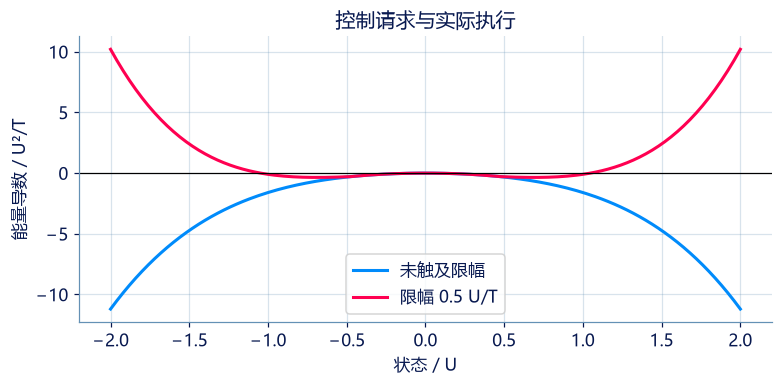

In [4]:
xs=np.linspace(-2,2,201)
free=[nonlinear_feedback(x,.4,.8,.8,1.2,100.)[3] for x in xs]
capped=[nonlinear_feedback(x,.4,.8,.8,1.2,.5)[3] for x in xs]
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(xs,free,label="未触及限幅",color=BLUE);ax.plot(xs,capped,label="限幅 0.5 U/T",color=PINK);ax.axhline(0,color="black",lw=.8);ax.set(xlabel="状态 / U",ylabel="能量导数 / U²/T",title="控制请求与实际执行");ax.legend();ax.grid(alpha=.25);plt.show()

## 结果解释

无饱和的解析不等式覆盖全状态；同一控制律经限幅后，大扰动可出现正能量导数，不能沿用原全局结论。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
for x in [.1,.5,1.,2.]:
    requested,actual,rate,vdot=nonlinear_feedback(x,.4,.8,.8,1.2,100.)
    np.testing.assert_allclose(vdot,-1.2*x*x-.4*x**4)
assert nonlinear_feedback(2.,.4,.8,.8,1.2,.5)[3]>0
print("未饱和解析式与饱和反例通过。")

未饱和解析式与饱和反例通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/16-01-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8F%8D%E9%A6%88%E8%AE%BE%E8%AE%A1/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：哪一个输入进入能量导数

请求输入（input）超过执行上限时，检验 V 的导数（derivative）应使用什么？

- **A.** 饱和后实际施加的输入。
- **B.** 未限幅的请求值。
- **C.** 图中最平滑的曲线。
- **D.** 训练时希望的目标。

[作答：哪一个输入进入能量导数](http://127.0.0.1:8000/chapters/16-01-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8F%8D%E9%A6%88%E8%AE%BE%E8%AE%A1/practice/?question=p16-lyapunov-actual)

### 第 2 题 · 单项选择题：三次反馈的充分条件

在无饱和模型（model） V=x²/2、a+k>0 时，哪一条件使四次项不增加 V？

- **A.** c<β。
- **B.** c≥β。
- **C.** 任意 c<0。
- **D.** 只要初态为零。

[作答：三次反馈的充分条件](http://127.0.0.1:8000/chapters/16-01-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8F%8D%E9%A6%88%E8%AE%BE%E8%AE%A1/practice/?question=p16-cubic-condition)

### 第 3 题 · Python 计算题：实际输入下的能量导数

给定状态（state）和执行上限，返回请求输入（input）、实际输入、状态导数（derivative）及 V=x²/2 的导数。

**函数与代码模板**

```python
def solve(
    x: float,
    a: float,
    beta: float,
    k: float,
    c: float,
    limit: float,
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x` | `float` | 当前状态。 | U |
| `a` | `float` | 线性恢复率。 | 1/T |
| `beta` | `float` | 三次非线性系数。 | 1/(U²T) |
| `k` | `float` | 线性反馈（feedback）系数。 | 1/T |
| `c` | `float` | 三次反馈系数。 | 1/(U²T) |
| `limit` | `float` | 输入绝对上限。 | U/T |

**返回值**

直接返回 result（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `result` | `list[float]` | 依次为请求输入、实际输入、状态导数和能量导数。 | 混合 |

**计算规则**

请求输入 -k*x-c*x³；实际输入截到 [-limit,limit]；状态率 -a*x+beta*x³+实际输入；V=x²/2 的变化率为 x*状态率。

**约束与边界**

- limit>0；参数（parameter）和状态均为有限数值。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x | 当前状态。 | 1 | U |
| a | 线性恢复率。 | 1 | 1/T |
| beta | 三次非线性系数。 | 0.5 | 1/(U²T) |
| k | 线性反馈（feedback）系数。 | 1 | 1/T |
| c | 三次反馈系数。 | 0.5 | 1/(U²T) |
| limit | 输入绝对上限。 | 0.5 | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x = 1.0
a = 1.0
beta = 0.5
k = 1.0
c = 0.5
limit = 0.5

result = solve(x, a, beta, k, c, limit)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| result | 依次为请求输入、实际输入、状态导数和能量导数。 | [-1.5, -0.5, -1.0, -1.0] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [-1.5, -0.5, -1.0, -1.0]
```

**样例解释**

首例请求输入为 -1.5，实际截为 -0.5；代入真实状态方程再计算 x·dx/dt。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：实际输入下的能量导数](http://127.0.0.1:8000/chapters/16-01-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8F%8D%E9%A6%88%E8%AE%BE%E8%AE%A1/practice/?question=p16-actual-lyapunov)

### 第 4 题 · Python 计算题：限幅反馈的离散路径

按显式 Euler 和每步实际限幅输入（input）返回状态（state）路径与输入路径。

**函数与代码模板**

```python
def solve(
    x0: float,
    a: float,
    beta: float,
    k: float,
    c: float,
    limit: float,
    h: float,
    steps: int,
) -> tuple[list[float], list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 初始状态。 | U |
| `a` | `float` | 线性恢复率。 | 1/T |
| `beta` | `float` | 三次系数。 | 1/(U²T) |
| `k` | `float` | 线性反馈（feedback）系数。 | 1/T |
| `c` | `float` | 三次反馈系数。 | 1/(U²T) |
| `limit` | `float` | 输入绝对上限。 | U/T |
| `h` | `float` | Euler 步长。 | T |
| `steps` | `int` | 更新步数。 | 步 |

**返回值**

按以下顺序返回元组：(states, inputs)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 含初态的状态路径。 | U |
| `inputs` | `list[float]` | 每步实际输入。 | U/T |

**计算规则**

每步先按当前状态求实际限幅输入，再用显式 Euler 推进；返回含初态的状态和每步实际输入。

**约束与边界**

- limit>0、h>0，0≤steps≤100；参数（parameter）和初态有限，生成路径保持有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 初始状态。 | 1 | U |
| a | 线性恢复率。 | 1 | 1/T |
| beta | 三次系数。 | 0 | 1/(U²T) |
| k | 线性反馈（feedback）系数。 | 1 | 1/T |
| c | 三次反馈系数。 | 0 | 1/(U²T) |
| limit | 输入绝对上限。 | 0.5 | U/T |
| h | Euler 步长。 | 0.1 | T |
| steps | 更新步数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 1.0
a = 1.0
beta = 0.0
k = 1.0
c = 0.0
limit = 0.5
h = 0.1
steps = 2

result = solve(x0, a, beta, k, c, limit, h, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 含初态的状态路径。 | [1.0, 0.85, 0.715] | U |
| inputs | 每步实际输入。 | [-0.5, -0.5] | U/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.0, 0.85, 0.715], [-0.5, -0.5])
```

**样例解释**

首步限幅输入为 -0.5，故首步变化率 -1.5，状态由1变为0.85。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：限幅反馈的离散路径](http://127.0.0.1:8000/chapters/16-01-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8F%8D%E9%A6%88%E8%AE%BE%E8%AE%A1/practice/?question=p16-feedback-path)

**进一步阅读**

[Boyd 等的 LMI 专著](https://web.stanford.edu/~boyd/lmibook/)给出二次函数与控制设计背景；此节为可手算标量教学例。